# Exploratory Data Analysis of the Selected PlantVillage Crop-Disease Subset

This notebook performs a reproducible EDA of the selected PlantVillage subset:
corn, tomato, potato, bell pepper, and soybean.

The analysis includes:
- Dataset integrity and cleaned evaluation partition creation
- Class and crop distributions
- Train–validation balance
- Healthy versus diseased composition
- Image metadata and colour statistics
- Visual sample inspection
- Exact and perceptual near-duplicate candidate audits
- Export of publication-ready figures, tables, and EDA findings

In [8]:
import os
import re
import json
import random
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageOps
from tqdm.auto import tqdm

# -------------------------------
# Reproducibility
# -------------------------------
SEED = 7
random.seed(SEED)
np.random.seed(SEED)

# -------------------------------
# Global paper-style settings
# -------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,

    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "axes.linewidth": 1.2,

    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "legend.fontsize": 11,
    "legend.frameon": True,
    "legend.edgecolor": "0.4",

    "grid.linestyle": ":",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.85,
})

def paper_axes(ax):
    ax.minorticks_on()
    ax.grid(True, which="major", linestyle=":", linewidth=0.8)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.7)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    ax.tick_params(which="both", direction="in", top=True, right=True)

PLANTVILLAGE_ROOT = Path(
    "/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage"
)

# -------------------------------
# Paths
# -------------------------------
WORK_DIR = Path("/kaggle/working")
MANIFEST_PATH = Path(
    "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/"
    "plantvillage_selected_manifest.csv"
)
OUTPUT_DIR = WORK_DIR / "eda_outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

assert PLANTVILLAGE_ROOT.exists(), (
    f"PlantVillage directory not found:\n{PLANTVILLAGE_ROOT}"
)

assert MANIFEST_PATH.exists(), (
    f"Manifest not found:\n{MANIFEST_PATH}\n\n"
    "Make sure the 'crop-manifestfiles' dataset is attached "
    "to the current EDA notebook."
)

print("PlantVillage images:", PLANTVILLAGE_ROOT)
print("Manifest file:", MANIFEST_PATH)
print("EDA output directory:", OUTPUT_DIR)
print("Manifest:", MANIFEST_PATH)
print("EDA output directory:", OUTPUT_DIR)

PlantVillage images: /kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage
Manifest file: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/plantvillage_selected_manifest.csv
EDA output directory: /kaggle/working/eda_outputs
Manifest: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/plantvillage_selected_manifest.csv
EDA output directory: /kaggle/working/eda_outputs


In [9]:
manifest = pd.read_csv(MANIFEST_PATH)

print("Manifest shape:", manifest.shape)
print("Manifest columns:")
print(manifest.columns.tolist())

first_image = Path(manifest.loc[0, "image_path"])

print("\nFirst image path in manifest:")
print(first_image)

print("\nDoes that PlantVillage image exist?")
print(first_image.exists())

Manifest shape: (31729, 16)
Manifest columns:
['image_path', 'relative_path', 'split', 'source_class_folder', 'crop', 'disease', 'label', 'is_healthy', 'file_name', 'file_extension', 'file_size_kb', 'width', 'height', 'sha256', 'phash', 'is_corrupt']

First image path in manifest:
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/train/Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot/00120a18-ff90-46e4-92fb-2b7a10345bd3___RS_GLSp 9357.JPG

Does that PlantVillage image exist?
True


In [10]:
manifest = pd.read_csv(MANIFEST_PATH)

required_columns = {
    "image_path", "split", "crop", "disease",
    "label", "is_healthy", "sha256", "phash", "is_corrupt"
}

missing_columns = required_columns - set(manifest.columns)
assert not missing_columns, f"Missing manifest columns: {missing_columns}"

print("Original manifest shape:", manifest.shape)
display(manifest.head(3))

# Identify SHA-256 hashes occurring in the original training partition.
train_hashes = set(
    manifest.loc[manifest["split"].eq("train"), "sha256"]
    .dropna()
    .astype(str)
)

# Exclude only validation images with an identical image in training.
manifest["exclude_from_evaluation"] = (
    manifest["split"].eq("val")
    & manifest["sha256"].astype(str).isin(train_hashes)
).astype(int)

manifest["evaluation_split"] = manifest["split"]
manifest.loc[
    manifest["exclude_from_evaluation"].eq(1),
    "evaluation_split"
] = "excluded_exact_duplicate"

clean_df = manifest.loc[
    manifest["exclude_from_evaluation"].eq(0)
].copy()

clean_manifest_path = TABLE_DIR / "plantvillage_selected_manifest_clean.csv"
excluded_path = TABLE_DIR / "excluded_exact_train_val_duplicates.csv"

clean_df.to_csv(clean_manifest_path, index=False)
manifest.loc[manifest["exclude_from_evaluation"].eq(1)].to_csv(
    excluded_path, index=False
)

print(f"Original images: {len(manifest):,}")
print(f"Excluded validation duplicates: {manifest['exclude_from_evaluation'].sum():,}")
print(f"Clean images retained: {len(clean_df):,}")
print(f"Clean train images: {(clean_df['split'] == 'train').sum():,}")
print(f"Clean validation images: {(clean_df['split'] == 'val').sum():,}")
print(f"Clean classes: {clean_df['label'].nunique()}")
print(f"Corrupt images in clean dataset: {clean_df['is_corrupt'].sum()}")

assert clean_df["is_corrupt"].sum() == 0, "Unexpected corrupt images found."
assert clean_df["label"].nunique() == 20, "Expected 20 selected classes."

Original manifest shape: (31729, 16)


,image_path,relative_path,split,source_class_folder,crop,disease,label,is_healthy,file_name,file_extension,file_size_kb,width,height,sha256,phash,is_corrupt
0,/kaggle/input/datasets/mohitsingh1804/plantvil...,train/Corn_(maize)___Cercospora_leaf_spot Gray...,train,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,corn,cercospora_leaf_spot_gray_leaf_spot,corn__cercospora_leaf_spot_gray_leaf_spot,0,00120a18-ff90-46e4-92fb-2b7a10345bd3___RS_GLSp...,.jpg,17.19,256,256,22733317743ff827be0f0e66036e068e8c93cf2f9779a0...,c0b826903fc0ffea,0
1,/kaggle/input/datasets/mohitsingh1804/plantvil...,train/Corn_(maize)___Cercospora_leaf_spot Gray...,train,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,corn,cercospora_leaf_spot_gray_leaf_spot,corn__cercospora_leaf_spot_gray_leaf_spot,0,00a20f6f-e8bd-4453-9e25-36ea70feb626___RS_GLSp...,.jpg,15.07,256,256,28afc642a85b24ee181315cb51f010400af8193653c080...,fe7023cf20611b4f,0
2,/kaggle/input/datasets/mohitsingh1804/plantvil...,train/Corn_(maize)___Cercospora_leaf_spot Gray...,train,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,corn,cercospora_leaf_spot_gray_leaf_spot,corn__cercospora_leaf_spot_gray_leaf_spot,0,0140764c-6157-4995-9ada-9c10b81af3b8___RS_GLSp...,.jpg,16.01,256,256,9c0e29744ac972c8901db9111c559b277e30754944c592...,ce9cf8a5232b6895,0


Original images: 31,729
Excluded validation duplicates: 5
Clean images retained: 31,724
Clean train images: 25,382
Clean validation images: 6,342
Clean classes: 20
Corrupt images in clean dataset: 0


In [11]:
overview = pd.DataFrame({
    "Metric": [
        "Selected crops",
        "Classes",
        "Original images",
        "Removed exact validation duplicates",
        "Clean images",
        "Training images",
        "Internal validation images",
        "Healthy images",
        "Diseased images",
        "Corrupt images"
    ],
    "Value": [
        clean_df["crop"].nunique(),
        clean_df["label"].nunique(),
        len(manifest),
        int(manifest["exclude_from_evaluation"].sum()),
        len(clean_df),
        int((clean_df["split"] == "train").sum()),
        int((clean_df["split"] == "val").sum()),
        int(clean_df["is_healthy"].sum()),
        int((clean_df["is_healthy"] == 0).sum()),
        int(clean_df["is_corrupt"].sum())
    ]
})

overview_path = TABLE_DIR / "dataset_overview.csv"
overview.to_csv(overview_path, index=False)

display(overview)
print(f"Saved: {overview_path}")

,Metric,Value
0,Selected crops,5
1,Classes,20
2,Original images,31729
3,Removed exact validation duplicates,5
4,Clean images,31724
5,Training images,25382
6,Internal validation images,6342
7,Healthy images,9471
8,Diseased images,22253
9,Corrupt images,0


Saved: /kaggle/working/eda_outputs/tables/dataset_overview.csv


In [12]:
class_summary = (
    clean_df
    .groupby(["crop", "disease", "label"], as_index=False)
    .agg(
        total_images=("image_path", "count"),
        train_images=("split", lambda x: int((x == "train").sum())),
        val_images=("split", lambda x: int((x == "val").sum())),
        healthy=("is_healthy", "max")
    )
    .sort_values("total_images", ascending=False)
    .reset_index(drop=True)
)

class_summary["train_fraction"] = (
    class_summary["train_images"] / class_summary["total_images"]
).round(4)

class_summary["val_fraction"] = (
    class_summary["val_images"] / class_summary["total_images"]
).round(4)

max_count = class_summary["total_images"].max()
min_count = class_summary["total_images"].min()
imbalance_ratio = max_count / min_count

class_summary_path = TABLE_DIR / "class_distribution_summary.csv"
class_summary.to_csv(class_summary_path, index=False)

print(f"Largest class size: {max_count:,}")
print(f"Smallest class size: {min_count:,}")
print(f"Maximum-to-minimum imbalance ratio: {imbalance_ratio:.2f}:1")
display(class_summary)

print(f"Saved: {class_summary_path}")

Largest class size: 5,357
Smallest class size: 152
Maximum-to-minimum imbalance ratio: 35.24:1


,crop,disease,label,total_images,train_images,val_images,healthy,train_fraction,val_fraction
0,tomato,tomato_yellow_leaf_curl_virus,tomato__tomato_yellow_leaf_curl_virus,5357,4286,1071,0,0.8001,0.1999
1,soybean,healthy,soybean__healthy,5090,4072,1018,1,0.8000,0.2000
2,tomato,bacterial_spot,tomato__bacterial_spot,2127,1702,425,0,0.8002,0.1998
3,tomato,late_blight,tomato__late_blight,1906,1527,379,0,0.8012,0.1988
4,tomato,septoria_leaf_spot,tomato__septoria_leaf_spot,1771,1417,354,0,0.8001,0.1999
5,tomato,spider_mites_two_spotted_spider_mite,tomato__spider_mites_two_spotted_spider_mite,1676,1341,335,0,0.8001,0.1999
6,tomato,healthy,tomato__healthy,1589,1273,316,1,0.8011,0.1989
7,bell_pepper,healthy,bell_pepper__healthy,1478,1183,295,1,0.8004,0.1996
8,tomato,target_spot,tomato__target_spot,1404,1123,281,0,0.7999,0.2001
9,corn,common_rust,corn__common_rust,1192,953,239,0,0.7995,0.2005


Saved: /kaggle/working/eda_outputs/tables/class_distribution_summary.csv


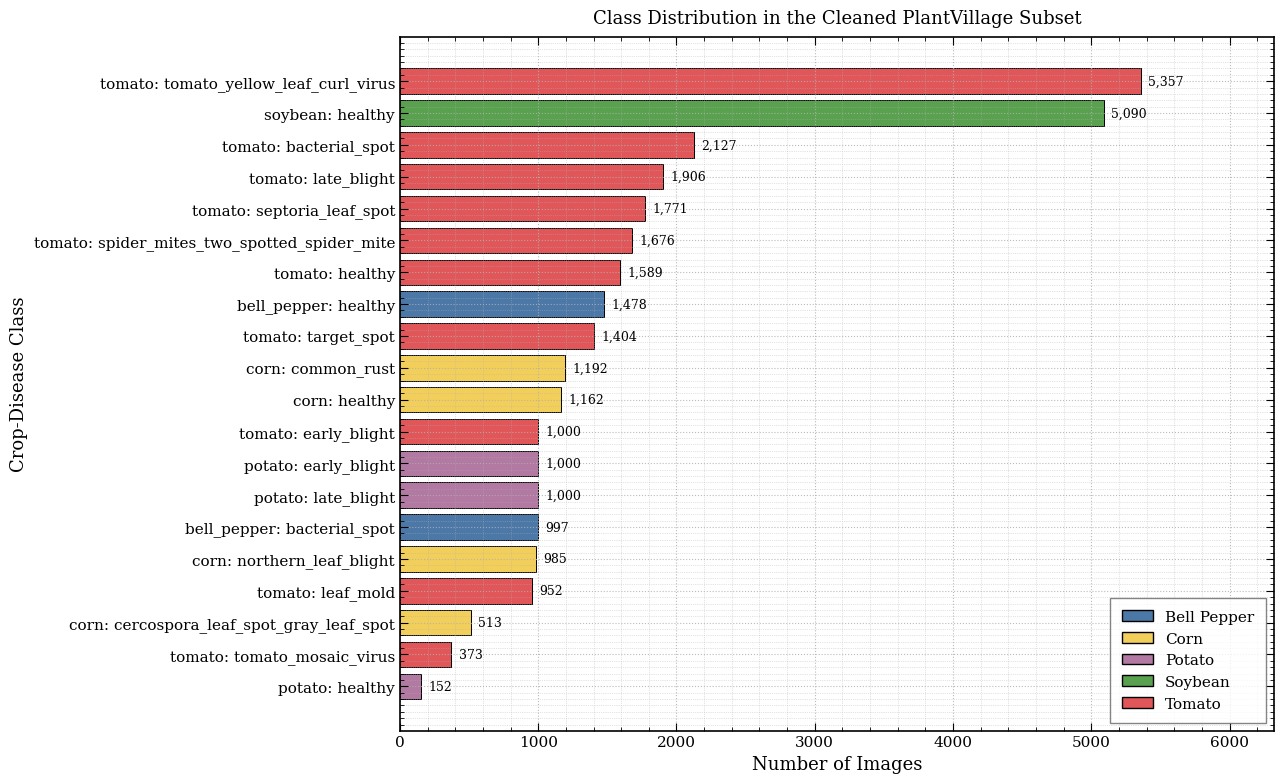

In [13]:
plot_df = class_summary.sort_values("total_images", ascending=True).copy()

crop_colors = {
    "bell_pepper": "#4C78A8",
    "corn": "#F2CF5B",
    "potato": "#B279A2",
    "soybean": "#59A14F",
    "tomato": "#E15759",
}

bar_colors = plot_df["crop"].map(crop_colors)

fig, ax = plt.subplots(figsize=(13, 8))

ax.barh(
    plot_df["label"].str.replace("__", ": ", regex=False),
    plot_df["total_images"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.7
)

ax.set_xlabel("Number of Images")
ax.set_ylabel("Crop-Disease Class")
ax.set_title("Class Distribution in the Cleaned PlantVillage Subset", pad=10)

for i, value in enumerate(plot_df["total_images"]):
    ax.text(
        value + max_count * 0.01,
        i,
        f"{value:,}",
        va="center",
        fontsize=9
    )

legend_handles = [
    mpatches.Patch(facecolor=color, edgecolor="black", label=crop.replace("_", " ").title())
    for crop, color in crop_colors.items()
    if crop in plot_df["crop"].unique()
]

ax.legend(handles=legend_handles, loc="lower right", fancybox=False, borderpad=0.8)
ax.set_xlim(0, plot_df["total_images"].max() * 1.18)
paper_axes(ax)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_01_class_distribution.pdf", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig_01_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

,crop,images,classes,healthy_images,diseased_images
4,tomato,18155,10,1589,16566
3,soybean,5090,1,5090,0
1,corn,3852,4,1162,2690
0,bell_pepper,2475,2,1478,997
2,potato,2152,3,152,2000


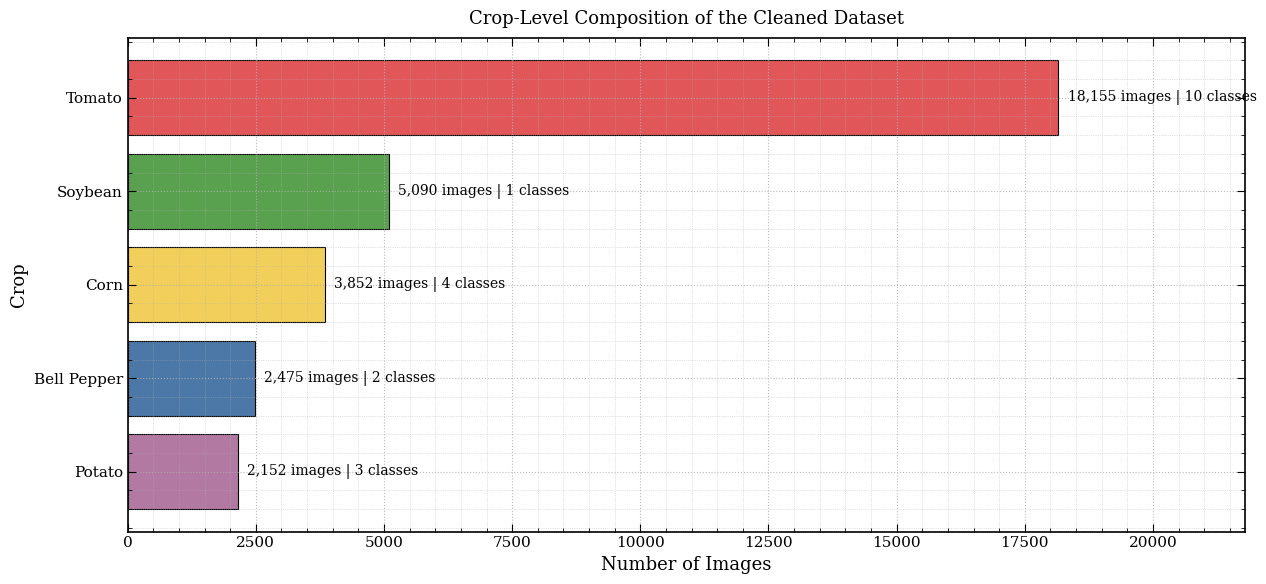

In [14]:
crop_summary = (
    clean_df
    .groupby("crop", as_index=False)
    .agg(
        images=("image_path", "count"),
        classes=("label", "nunique"),
        healthy_images=("is_healthy", "sum")
    )
    .sort_values("images", ascending=False)
)

crop_summary["diseased_images"] = (
    crop_summary["images"] - crop_summary["healthy_images"]
)

crop_summary_path = TABLE_DIR / "crop_distribution_summary.csv"
crop_summary.to_csv(crop_summary_path, index=False)

display(crop_summary)

plot_df = crop_summary.sort_values("images", ascending=True)

fig, ax = plt.subplots(figsize=(13, 6))

ax.barh(
    plot_df["crop"].str.replace("_", " ").str.title(),
    plot_df["images"],
    color=[crop_colors[c] for c in plot_df["crop"]],
    edgecolor="black",
    linewidth=0.8
)

for i, row in enumerate(plot_df.itertuples()):
    ax.text(
        row.images + crop_summary["images"].max() * 0.01,
        i,
        f"{row.images:,} images | {row.classes} classes",
        va="center",
        fontsize=10
    )

ax.set_xlabel("Number of Images")
ax.set_ylabel("Crop")
ax.set_title("Crop-Level Composition of the Cleaned Dataset", pad=10)
ax.set_xlim(0, crop_summary["images"].max() * 1.20)
paper_axes(ax)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_02_crop_distribution.pdf", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig_02_crop_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

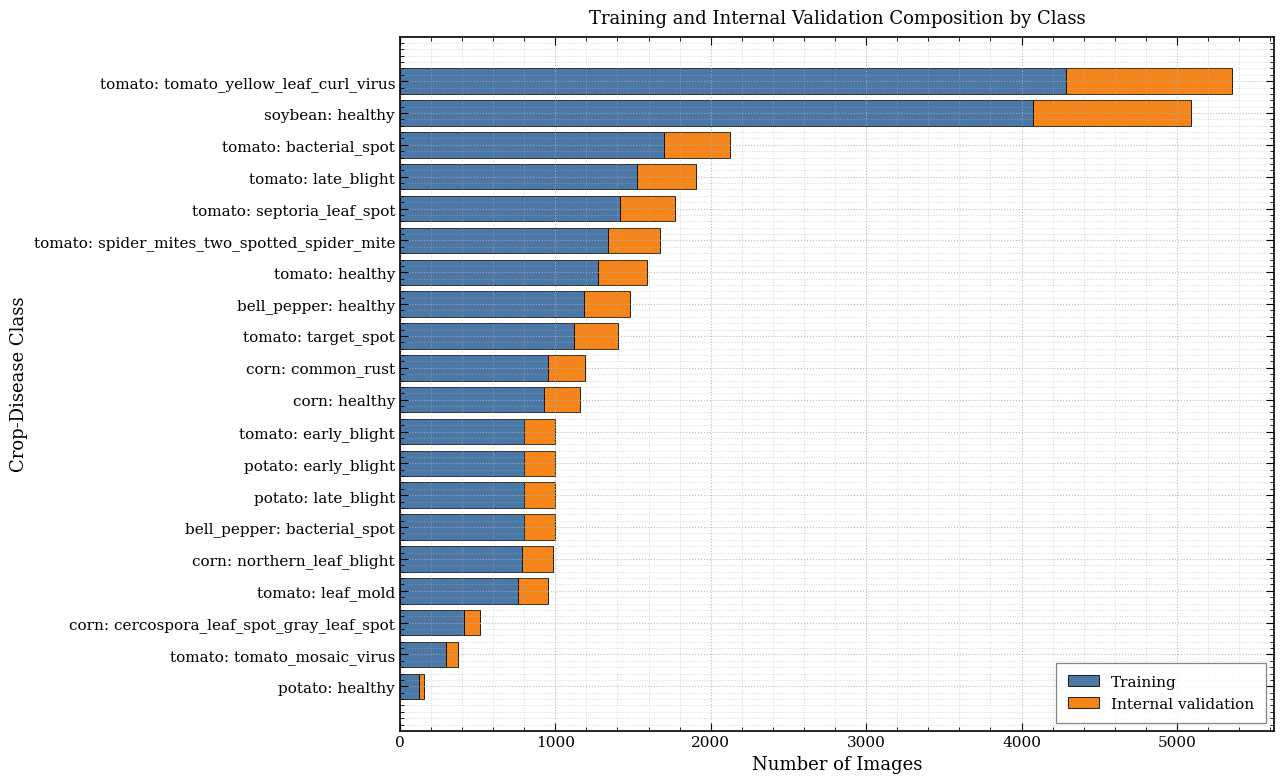

In [15]:
split_counts = (
    clean_df
    .groupby(["label", "split"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for column in ["train", "val"]:
    if column not in split_counts.columns:
        split_counts[column] = 0

split_counts = split_counts.merge(
    class_summary[["label", "crop", "total_images"]],
    on="label",
    how="left"
).sort_values("total_images", ascending=True)

labels = split_counts["label"].str.replace("__", ": ", regex=False)
y_pos = np.arange(len(split_counts))

fig, ax = plt.subplots(figsize=(13, 8))

ax.barh(
    y_pos,
    split_counts["train"],
    color="#4C78A8",
    edgecolor="black",
    linewidth=0.6,
    label="Training"
)

ax.barh(
    y_pos,
    split_counts["val"],
    left=split_counts["train"],
    color="#F58518",
    edgecolor="black",
    linewidth=0.6,
    label="Internal validation"
)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel("Number of Images")
ax.set_ylabel("Crop-Disease Class")
ax.set_title("Training and Internal Validation Composition by Class", pad=10)

leg = ax.legend(loc="lower right", fancybox=False, borderpad=0.8)
leg.get_frame().set_linewidth(0.9)

paper_axes(ax)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_03_train_validation_distribution.pdf", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig_03_train_validation_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

status,crop,Diseased,Healthy,Total,Healthy (%)
0,bell_pepper,997.0,1478.0,2475.0,59.72
1,corn,2690.0,1162.0,3852.0,30.17
2,potato,2000.0,152.0,2152.0,7.06
3,soybean,0.0,5090.0,5090.0,100.00
4,tomato,16566.0,1589.0,18155.0,8.75


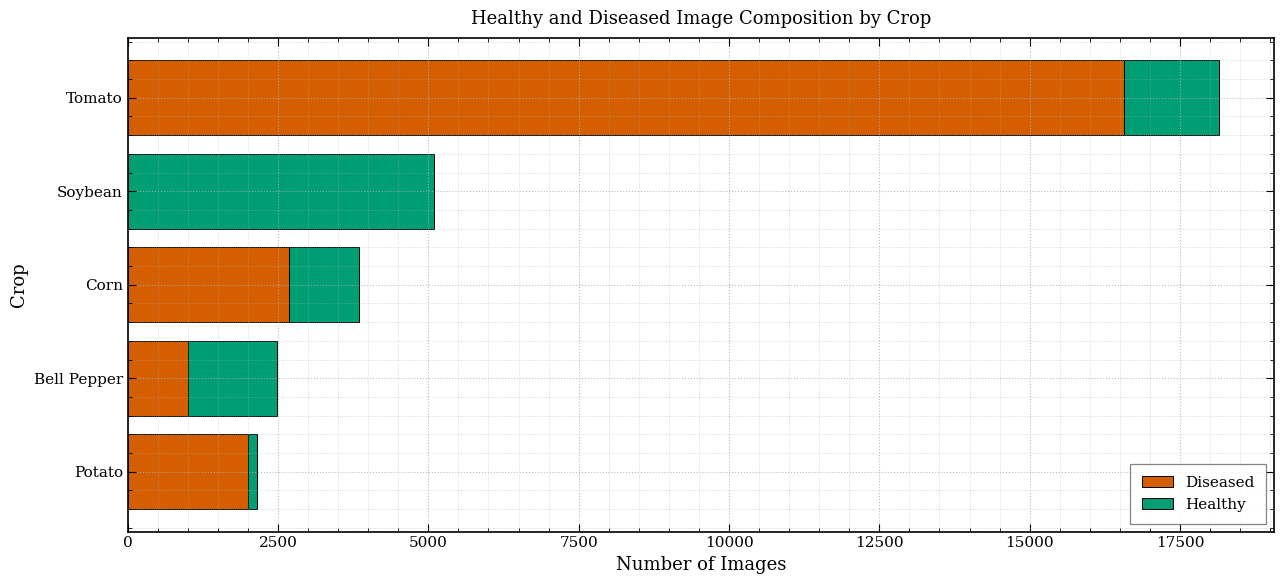

In [16]:
health_summary = (
    clean_df
    .assign(status=np.where(clean_df["is_healthy"].eq(1), "Healthy", "Diseased"))
    .groupby(["crop", "status"], as_index=False)
    .size()
    .rename(columns={"size": "images"})
)

health_pivot = (
    health_summary
    .pivot(index="crop", columns="status", values="images")
    .fillna(0)
)

for col in ["Healthy", "Diseased"]:
    if col not in health_pivot.columns:
        health_pivot[col] = 0

health_pivot["Total"] = health_pivot["Healthy"] + health_pivot["Diseased"]
health_pivot["Healthy (%)"] = (
    100 * health_pivot["Healthy"] / health_pivot["Total"]
).round(2)

health_summary_path = TABLE_DIR / "healthy_diseased_summary.csv"
health_pivot.reset_index().to_csv(health_summary_path, index=False)

display(health_pivot.reset_index())

plot_df = health_pivot.sort_values("Total", ascending=True)

fig, ax = plt.subplots(figsize=(13, 6))

ax.barh(
    plot_df.index.str.replace("_", " ").str.title(),
    plot_df["Diseased"],
    color="#D55E00",
    edgecolor="black",
    linewidth=0.7,
    label="Diseased"
)

ax.barh(
    plot_df.index.str.replace("_", " ").str.title(),
    plot_df["Healthy"],
    left=plot_df["Diseased"],
    color="#009E73",
    edgecolor="black",
    linewidth=0.7,
    label="Healthy"
)

ax.set_xlabel("Number of Images")
ax.set_ylabel("Crop")
ax.set_title("Healthy and Diseased Image Composition by Crop", pad=10)

leg = ax.legend(loc="lower right", fancybox=False, borderpad=0.8)
leg.get_frame().set_linewidth(0.9)

paper_axes(ax)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_04_healthy_diseased_by_crop.pdf", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig_04_healthy_diseased_by_crop.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
metadata_summary = (
    clean_df
    .groupby(["split", "crop"], as_index=False)
    .agg(
        images=("image_path", "count"),
        mean_width=("width", "mean"),
        std_width=("width", "std"),
        mean_height=("height", "mean"),
        std_height=("height", "std"),
        unique_widths=("width", "nunique"),
        unique_heights=("height", "nunique")
    )
)

metadata_summary_path = TABLE_DIR / "image_metadata_summary.csv"
metadata_summary.to_csv(metadata_summary_path, index=False)

display(metadata_summary)

width_counts = clean_df["width"].value_counts(dropna=False).sort_index()
height_counts = clean_df["height"].value_counts(dropna=False).sort_index()

print("Width distribution:")
display(width_counts.to_frame("images"))

print("Height distribution:")
display(height_counts.to_frame("images"))

assert clean_df["width"].nunique() == 1, "Unexpected width variation detected."
assert clean_df["height"].nunique() == 1, "Unexpected height variation detected."

print(
    f"All clean images have fixed dimensions: "
    f"{clean_df['width'].iloc[0]} × {clean_df['height'].iloc[0]} pixels."
)

,split,crop,images,mean_width,std_width,mean_height,std_height,unique_widths,unique_heights
0,train,bell_pepper,1980,256.0,0.0,256.0,0.0,1,1
1,train,corn,3080,256.0,0.0,256.0,0.0,1,1
2,train,potato,1721,256.0,0.0,256.0,0.0,1,1
3,train,soybean,4072,256.0,0.0,256.0,0.0,1,1
4,train,tomato,14529,256.0,0.0,256.0,0.0,1,1
5,val,bell_pepper,495,256.0,0.0,256.0,0.0,1,1
6,val,corn,772,256.0,0.0,256.0,0.0,1,1
7,val,potato,431,256.0,0.0,256.0,0.0,1,1
8,val,soybean,1018,256.0,0.0,256.0,0.0,1,1
9,val,tomato,3626,256.0,0.0,256.0,0.0,1,1


Width distribution:


,images
width,
256,31724


Height distribution:


,images
height,
256,31724


All clean images have fixed dimensions: 256 × 256 pixels.


In [18]:
def compute_rgb_statistics(image_path):
    try:
        with Image.open(image_path) as image:
            image = ImageOps.exif_transpose(image).convert("RGB")
            array = np.asarray(image, dtype=np.float32) / 255.0

        mean_rgb = array.mean(axis=(0, 1))
        std_rgb = array.std(axis=(0, 1))

        return {
            "r_mean": mean_rgb[0],
            "g_mean": mean_rgb[1],
            "b_mean": mean_rgb[2],
            "r_std": std_rgb[0],
            "g_std": std_rgb[1],
            "b_std": std_rgb[2],
            "read_error": 0
        }

    except Exception:
        return {
            "r_mean": np.nan,
            "g_mean": np.nan,
            "b_mean": np.nan,
            "r_std": np.nan,
            "g_std": np.nan,
            "b_std": np.nan,
            "read_error": 1
        }

# A reproducible stratified sample makes RGB analysis computationally practical.
SAMPLES_PER_CLASS = 150

rgb_sample = (
    clean_df
    .groupby("label", group_keys=False)
    .apply(
        lambda group: group.sample(
            n=min(SAMPLES_PER_CLASS, len(group)),
            random_state=SEED
        )
    )
    .reset_index(drop=True)
)

print(f"RGB analysis sample size: {len(rgb_sample):,}")

rgb_records = []

for row in tqdm(
    rgb_sample.itertuples(index=False),
    total=len(rgb_sample),
    desc="Computing RGB statistics"
):
    stats = compute_rgb_statistics(row.image_path)

    rgb_records.append({
        "image_path": row.image_path,
        "label": row.label,
        "crop": row.crop,
        "split": row.split,
        **stats
    })

rgb_df = pd.DataFrame(rgb_records)

rgb_image_path = TABLE_DIR / "rgb_image_statistics_sample.csv"
rgb_df.to_csv(rgb_image_path, index=False)

rgb_class_summary = (
    rgb_df
    .groupby(["crop", "label"], as_index=False)
    .agg(
        sampled_images=("image_path", "count"),
        r_mean=("r_mean", "mean"),
        g_mean=("g_mean", "mean"),
        b_mean=("b_mean", "mean"),
        r_std=("r_std", "mean"),
        g_std=("g_std", "mean"),
        b_std=("b_std", "mean")
    )
)

rgb_class_summary_path = TABLE_DIR / "rgb_class_statistics.csv"
rgb_class_summary.to_csv(rgb_class_summary_path, index=False)

print(f"Read errors: {rgb_df['read_error'].sum()}")
display(rgb_class_summary.head())

RGB analysis sample size: 3,000


/tmp/ipykernel_58/2160425805.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


Computing RGB statistics:   0%|          | 0/3000 [00:00<?, ?it/s]

Read errors: 0


,crop,label,sampled_images,r_mean,g_mean,b_mean,r_std,g_std,b_std
0,bell_pepper,bell_pepper__bacterial_spot,150,0.470592,0.481378,0.388320,0.215973,0.187424,0.229231
1,bell_pepper,bell_pepper__healthy,150,0.481087,0.531781,0.450520,0.214536,0.164764,0.226169
2,corn,corn__cercospora_leaf_spot_gray_leaf_spot,150,0.462658,0.485202,0.384714,0.164614,0.142638,0.172494
3,corn,corn__common_rust,150,0.344363,0.379015,0.267629,0.248436,0.264596,0.210876
4,corn,corn__healthy,150,0.495854,0.636730,0.481745,0.139336,0.119433,0.148746


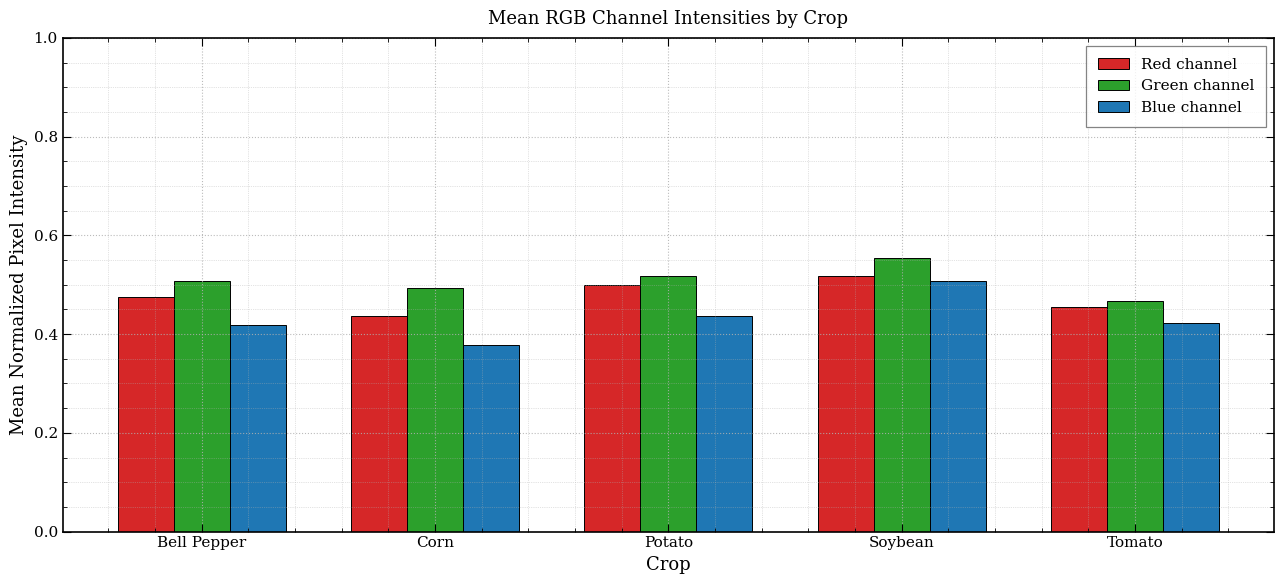

In [19]:
rgb_crop_summary = (
    rgb_df
    .groupby("crop", as_index=False)[["r_mean", "g_mean", "b_mean"]]
    .mean()
    .sort_values("crop")
)

x = np.arange(len(rgb_crop_summary))
bar_width = 0.24

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(
    x - bar_width,
    rgb_crop_summary["r_mean"],
    width=bar_width,
    color="#D62728",
    edgecolor="black",
    linewidth=0.7,
    label="Red channel"
)

ax.bar(
    x,
    rgb_crop_summary["g_mean"],
    width=bar_width,
    color="#2CA02C",
    edgecolor="black",
    linewidth=0.7,
    label="Green channel"
)

ax.bar(
    x + bar_width,
    rgb_crop_summary["b_mean"],
    width=bar_width,
    color="#1F77B4",
    edgecolor="black",
    linewidth=0.7,
    label="Blue channel"
)

ax.set_xticks(x)
ax.set_xticklabels(
    rgb_crop_summary["crop"].str.replace("_", " ").str.title()
)
ax.set_ylim(0, 1)
ax.set_xlabel("Crop")
ax.set_ylabel("Mean Normalized Pixel Intensity")
ax.set_title("Mean RGB Channel Intensities by Crop", pad=10)

leg = ax.legend(loc="upper right", fancybox=False, borderpad=0.8)
leg.get_frame().set_linewidth(0.9)

paper_axes(ax)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_05_rgb_channel_statistics.pdf", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig_05_rgb_channel_statistics.png", dpi=300, bbox_inches="tight")
plt.show()

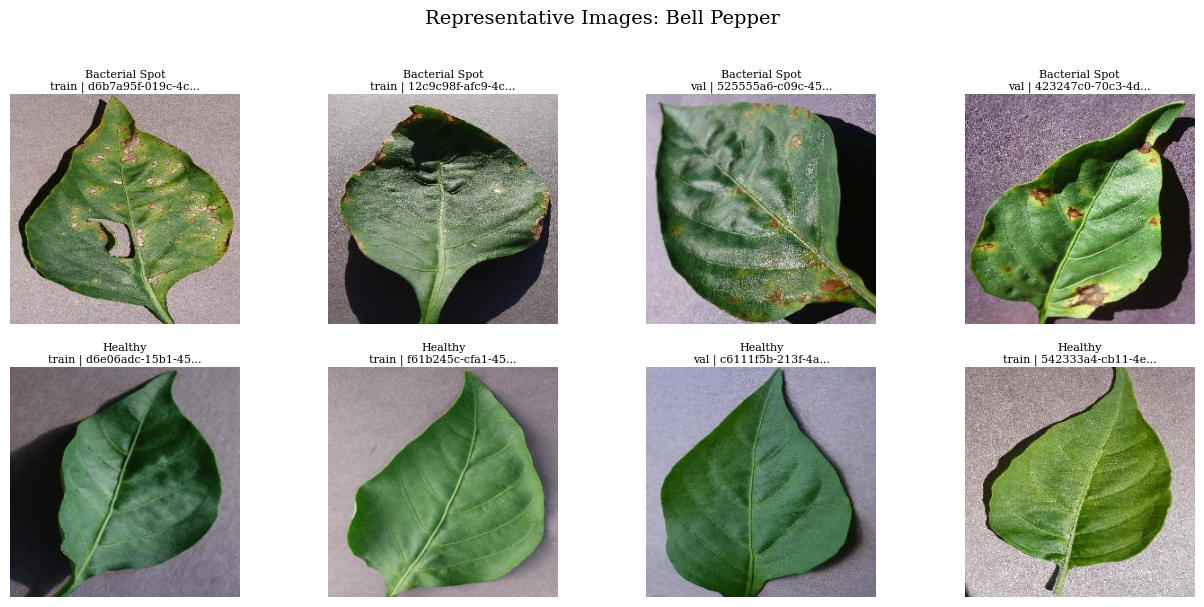

In [ ]:
SAMPLES_PER_CLASS_GRID = 4

for crop in sorted(clean_df["crop"].unique()):
    crop_df = clean_df.loc[clean_df["crop"].eq(crop)].copy()
    labels = sorted(crop_df["label"].unique())

    n_rows = len(labels)
    n_cols = SAMPLES_PER_CLASS_GRID

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(13, max(3.0 * n_rows, 6)),
        squeeze=False
    )

    for row_idx, label in enumerate(labels):
        label_df = crop_df.loc[crop_df["label"].eq(label)]

        sampled = label_df.sample(
            n=min(SAMPLES_PER_CLASS_GRID, len(label_df)),
            random_state=SEED
        ).reset_index(drop=True)

        for col_idx in range(n_cols):
            ax = axes[row_idx, col_idx]
            ax.axis("off")

            if col_idx < len(sampled):
                row = sampled.iloc[col_idx]

                with Image.open(row["image_path"]) as image:
                    image = ImageOps.exif_transpose(image).convert("RGB")
                    ax.imshow(image)

                short_label = row["disease"].replace("_", " ").title()
                ax.set_title(
                    f"{short_label}\n{row['split']} | {row['file_name'][:16]}...",
                    fontsize=8,
                    pad=4
                )

        axes[row_idx, 0].set_ylabel(
            label.replace("__", "\n"),
            rotation=0,
            ha="right",
            va="center",
            fontsize=9,
            labelpad=85
        )

    fig.suptitle(
        f"Representative Images: {crop.replace('_', ' ').title()}",
        fontsize=14,
        y=1.01
    )

    plt.tight_layout()

    safe_crop = crop.replace("_", "-")
    plt.savefig(
        FIG_DIR / f"fig_samples_{safe_crop}.pdf",
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        FIG_DIR / f"fig_samples_{safe_crop}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [ ]:
train_phash = set(
    clean_df.loc[clean_df["split"].eq("train"), "phash"]
    .dropna()
    .astype(str)
)

val_phash = set(
    clean_df.loc[clean_df["split"].eq("val"), "phash"]
    .dropna()
    .astype(str)
)

shared_phashes = train_phash.intersection(val_phash)

phash_exact_matches = (
    clean_df.loc[clean_df["phash"].astype(str).isin(shared_phashes)]
    .sort_values(["phash", "split", "image_path"])
    .copy()
)

phash_exact_path = TABLE_DIR / "cross_split_exact_phash_matches.csv"
phash_exact_matches.to_csv(phash_exact_path, index=False)

print(f"Cross-split exact perceptual-hash matches: {len(shared_phashes):,}")
print(f"Images involved: {len(phash_exact_matches):,}")
print(f"Saved: {phash_exact_path}")

if len(phash_exact_matches) > 0:
    display(
        phash_exact_matches[
            ["split", "label", "file_name", "phash", "image_path"]
        ].head(20)
    )
else:
    print("No exact perceptual-hash matches remain after SHA-256 duplicate removal.")

In [ ]:
def hamming_distance(hex_hash_1, hex_hash_2):
    return int(hex_hash_1, 16).bit_count() ^ int(hex_hash_2, 16).bit_count()

# Correction: XOR first, then count differing bits.
def phash_hamming_distance(hex_hash_1, hex_hash_2):
    return (int(hex_hash_1, 16) ^ int(hex_hash_2, 16)).bit_count()

# Threshold is intentionally conservative.
# A candidate is NOT automatically a duplicate; it requires visual review.
HAMMING_THRESHOLD = 4
PREFIX_LENGTH = 4

near_duplicate_records = []

for label in tqdm(
    sorted(clean_df["label"].unique()),
    desc="Scanning classes"
):
    label_df = clean_df.loc[
        clean_df["label"].eq(label) & clean_df["phash"].notna()
    ].copy()

    train_label = label_df.loc[label_df["split"].eq("train")]
    val_label = label_df.loc[label_df["split"].eq("val")]

    if train_label.empty or val_label.empty:
        continue

    # Compare only within same-label hash-prefix buckets.
    # This makes the search feasible and focuses on likely candidates.
    train_buckets = {}

    for row in train_label.itertuples(index=False):
        prefix = str(row.phash)[:PREFIX_LENGTH]
        train_buckets.setdefault(prefix, []).append(row)

    for val_row in val_label.itertuples(index=False):
        prefix = str(val_row.phash)[:PREFIX_LENGTH]

        for train_row in train_buckets.get(prefix, []):
            distance = phash_hamming_distance(
                str(train_row.phash),
                str(val_row.phash)
            )

            if distance <= HAMMING_THRESHOLD:
                near_duplicate_records.append({
                    "label": label,
                    "hamming_distance": distance,
                    "train_image_path": train_row.image_path,
                    "train_file_name": train_row.file_name,
                    "train_phash": train_row.phash,
                    "val_image_path": val_row.image_path,
                    "val_file_name": val_row.file_name,
                    "val_phash": val_row.phash
                })

near_duplicate_df = pd.DataFrame(near_duplicate_records)

if not near_duplicate_df.empty:
    near_duplicate_df = near_duplicate_df.sort_values(
        ["hamming_distance", "label"]
    ).reset_index(drop=True)

near_duplicate_path = TABLE_DIR / "near_duplicate_candidates_phash_hamming_le4.csv"
near_duplicate_df.to_csv(near_duplicate_path, index=False)

print(f"Near-duplicate candidates (Hamming distance ≤ {HAMMING_THRESHOLD}): {len(near_duplicate_df):,}")
print(f"Saved: {near_duplicate_path}")

if not near_duplicate_df.empty:
    display(near_duplicate_df.head(20))
else:
    print("No near-duplicate candidates were detected by this conservative screen.")

In [ ]:
MAX_CANDIDATES_TO_VISUALIZE = 20

if near_duplicate_df.empty:
    print("No near-duplicate candidates available for visual review.")

else:
    candidates = near_duplicate_df.head(MAX_CANDIDATES_TO_VISUALIZE).copy()
    n_rows = len(candidates)

    fig, axes = plt.subplots(
        n_rows,
        2,
        figsize=(13, max(3 * n_rows, 6)),
        squeeze=False
    )

    for idx, candidate in enumerate(candidates.itertuples(index=False)):
        for col, image_path, split_name, file_name in [
            (0, candidate.train_image_path, "Train", candidate.train_file_name),
            (1, candidate.val_image_path, "Validation", candidate.val_file_name)
        ]:
            ax = axes[idx, col]

            with Image.open(image_path) as image:
                image = ImageOps.exif_transpose(image).convert("RGB")
                ax.imshow(image)

            ax.set_title(
                f"{split_name}: {candidate.label.replace('__', ': ')}\n"
                f"Hamming distance = {candidate.hamming_distance}\n"
                f"{file_name[:40]}",
                fontsize=9
            )
            ax.axis("off")

    fig.suptitle(
        "Visual Review of Cross-Split Near-Duplicate Candidates",
        fontsize=14,
        y=1.002
    )

    plt.tight_layout()
    plt.savefig(
        FIG_DIR / "fig_06_near_duplicate_visual_review.pdf",
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        FIG_DIR / "fig_06_near_duplicate_visual_review.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

In [ ]:
largest_class = class_summary.iloc[0]
smallest_class = class_summary.iloc[-1]

soybean_summary = (
    clean_df.loc[clean_df["crop"].eq("soybean")]
    .groupby("is_healthy")
    .size()
    .to_dict()
)

near_candidate_count = len(near_duplicate_df)
exact_phash_count = len(shared_phashes)

findings = pd.DataFrame([
    {
        "Finding_ID": "EDA-01",
        "Observation": "Dataset integrity",
        "Quantitative_evidence": (
            f"{len(clean_df):,} clean images; "
            f"{clean_df['is_corrupt'].sum()} corrupt images."
        ),
        "Modelling_implication": (
            "No image-repair procedure is needed. Use the cleaned manifest as "
            "the single source of truth for all later notebooks."
        )
    },
    {
        "Finding_ID": "EDA-02",
        "Observation": "Cross-split exact duplicate leakage",
        "Quantitative_evidence": (
            f"{manifest['exclude_from_evaluation'].sum()} validation images "
            "were byte-identical to training samples and were excluded."
        ),
        "Modelling_implication": (
            "Use only the cleaned validation partition for final internal testing."
        )
    },
    {
        "Finding_ID": "EDA-03",
        "Observation": "Class imbalance",
        "Quantitative_evidence": (
            f"Largest class: {largest_class['label']} "
            f"({largest_class['total_images']:,}); smallest class: "
            f"{smallest_class['label']} ({smallest_class['total_images']:,}); "
            f"ratio = {imbalance_ratio:.2f}:1."
        ),
        "Modelling_implication": (
            "Use class-weighted cross-entropy or a weighted sampler; report "
            "macro-F1, balanced accuracy, per-class recall, and confusion matrices."
        )
    },
    {
        "Finding_ID": "EDA-04",
        "Observation": "Fixed resolution",
        "Quantitative_evidence": (
            f"All images are {int(clean_df['width'].iloc[0])} × "
            f"{int(clean_df['height'].iloc[0])} pixels."
        ),
        "Modelling_implication": (
            "Maintain aspect ratio; use model resizing only when required "
            "(e.g., 224 or 384 pixels), without arbitrary cropping."
        )
    },
    {
        "Finding_ID": "EDA-05",
        "Observation": "Soybean label limitation",
        "Quantitative_evidence": (
            f"Soybean contains {int(soybean_summary.get(1, 0)):,} healthy "
            "images and no diseased soybean category."
        ),
        "Modelling_implication": (
            "Exclude soybean from headline disease-detection metrics; report "
            "it separately as healthy soybean recognition or auxiliary robustness evidence."
        )
    },
    {
        "Finding_ID": "EDA-06",
        "Observation": "Near-duplicate candidate screen",
        "Quantitative_evidence": (
            f"{near_candidate_count:,} same-label cross-split candidates at "
            f"perceptual-hash Hamming distance ≤ {HAMMING_THRESHOLD}; "
            f"{exact_phash_count:,} exact pHash matches."
        ),
        "Modelling_implication": (
            "Visually inspect candidates before any additional exclusions. "
            "Document all final decisions in the leakage audit."
        )
    },
    {
        "Finding_ID": "EDA-07",
        "Observation": "Controlled-image environment",
        "Quantitative_evidence": (
            "Images have uniform 256 × 256 resolution and visually controlled "
            "PlantVillage-style acquisition conditions."
        ),
        "Modelling_implication": (
            "Use colour, illumination, blur, and background-oriented augmentations; "
            "later evaluate external generalization on PlantDoc."
        )
    }
])

findings_path = TABLE_DIR / "eda_findings_and_modelling_implications.csv"
findings.to_csv(findings_path, index=False)

display(findings)
print(f"Saved: {findings_path}")

In [ ]:
final_report = {
    "dataset_name": "PlantVillage selected crop subset",
    "selected_crops": sorted(clean_df["crop"].unique().tolist()),
    "clean_images": int(len(clean_df)),
    "classes": int(clean_df["label"].nunique()),
    "train_images": int((clean_df["split"] == "train").sum()),
    "internal_validation_images": int((clean_df["split"] == "val").sum()),
    "removed_exact_validation_duplicates": int(
        manifest["exclude_from_evaluation"].sum()
    ),
    "corrupt_images": int(clean_df["is_corrupt"].sum()),
    "largest_class": str(largest_class["label"]),
    "largest_class_images": int(largest_class["total_images"]),
    "smallest_class": str(smallest_class["label"]),
    "smallest_class_images": int(smallest_class["total_images"]),
    "class_imbalance_ratio": round(float(imbalance_ratio), 4),
    "near_duplicate_candidates_hamming_le_4": int(near_candidate_count),
    "random_seed": SEED
}

report_path = OUTPUT_DIR / "eda_report.json"

with open(report_path, "w") as file:
    json.dump(final_report, file, indent=4)

print("EDA completed successfully.\n")
print(json.dumps(final_report, indent=4))

print("\nFigures:")
for path in sorted(FIG_DIR.glob("*")):
    print("-", path.name)

print("\nTables:")
for path in sorted(TABLE_DIR.glob("*")):
    print("-", path.name)